### Librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from config import make_pca_config
from data_loader import load_price_panel
from backtest import run_backtest
from performance import summarize_backtest
from plots import *

### Load data

In [2]:
file_map_5 = {
    "AD1": "data_elsa\AD1_COMB_Curncy.xlsx",
    "CD1": "data_elsa\CD1_COMB_Curncy.xlsx", 
    "EC1": "data_elsa\EC1_COMB_Curncy.xlsx",
    "SF1": "data_elsa\SF1_COMB_Curncy.xlsx" 
}

file_map_6 = {
    "C1": "data_elsa\C1_COMB_Comdty.xlsx",
    "C01": "data_elsa\CO1_Comdty.xlsx", 
    "CL1": "data_elsa\CL1_COMB_Comdty.xlsx",
    "GC1": "data_elsa\GC1_COMB_Comdty.xlsx",
    "GX1": "data_elsa\GX1_Index.xlsx",
    "HG1": "data_elsa\HG1_COMB_Comdty.xlsx",
    "HI1": "data_elsa\HI1_COMB_Index.xlsx",
    "LA1": "data_elsa\LA1_Comdty.xlsx",
    "NQ1": "data_elsa\_NQ1_Index.xlsx",
    "VG1": "data_elsa\VG1_Index.xlsx",
    "W1": "data_elsa\W1_COMB_Comdty.xlsx"
}

prices_5 = load_price_panel(file_map=file_map_5, sheet_name=0, header=5, date_col="Date", price_col="PX_LAST")
prices_6 = load_price_panel(file_map=file_map_6, sheet_name=0, header=6, date_col="Date", price_col="PX_LAST")
prices = pd.concat([prices_5, prices_6], axis=1)
# prices = prices.dropna()
prices.isna().sum()

AD1     157
CD1     160
EC1     161
SF1     158
C1      198
C01      51
CL1     212
GC1     212
GX1     108
HG1     212
HI1     266
LA1    6539
NQ1     156
VG1     108
W1      198
dtype: int64

In [3]:
prices = prices.drop(columns=["LA1", "CL1"])
prices = prices.interpolate(method='linear', limit_direction='both')
prices.isna().sum()

AD1    0
CD1    0
EC1    0
SF1    0
C1     0
C01    0
GC1    0
GX1    0
HG1    0
HI1    0
NQ1    0
VG1    0
W1     0
dtype: int64

### Run strategy

In [4]:
# Config
config = make_pca_config()
config.pca_mode = "variance"
config.explained_variance_target = 0.55
config.sbo = 1.75
config.sso = 2.25
config.sbc = 0.5
config.ssc = 0.5

config.use_factor_neutral_overlay = True
config.neutralize_net_exposure = False
config.max_single_position = 0.1

config.entry_weight_mode = "constant"
config.no_trade_band = 0.005
config.gross_sizing_mode = "natural"

config.store_snapshots = True
config.snapshot_start = "2020-04-18"
config.snapshot_end = "2020-04-26"
# config.snapshot_dates = ["2006-01-31", "2006-02-15", "2006-03-31"]

config.validate()

In [5]:
# Run
result = run_backtest(prices, config)
print("Diagnostics columns:")
print(result.diagnostics.columns.tolist())

Diagnostics columns:
['n_assets', 'n_factors', 'selected_variance', 'n_longs', 'n_shorts', 'gross_long', 'gross_short', 'gross', 'net', 'turnover', 'trade_count', 'impact_cost', 'max_abs_factor_exposure', 'beta_factor_1', 'beta_factor_2', 'beta_factor_3', 'beta_factor_4']


In [6]:
summary_fixed = summarize_backtest(
    equity_curve=result.equity_curve,
    daily_returns=result.daily_returns,
    turnover=result.turnover,
    nb_trades= result.total_trade_count
)

summary_fixed

total_return           -0.007731
annualized_return      -0.000299
annualized_vol          0.013137
sharpe                 -0.016202
max_drawdown           -0.062685
hit_ratio               0.494877
nb_trades            3948.000000
avg_turnover            0.033637
median_turnover         0.000000
Name: performance, dtype: float64

### Strategy analysis

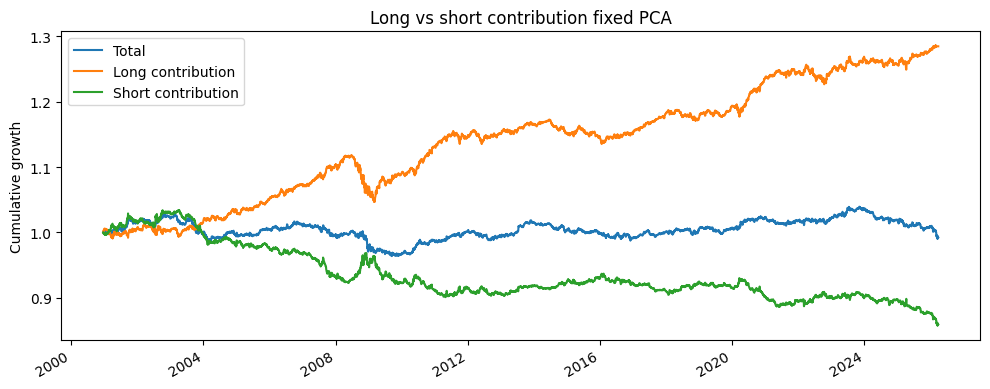

In [7]:
plot_long_short_contribution(
    total_returns=result.daily_returns,
    long_contribution=result.long_contribution,
    short_contribution=result.short_contribution,
    title="Long vs short contribution fixed PCA"
)

In [8]:
diag = result.diagnostics.copy()
beta_cols = [c for c in diag.columns if c.startswith("beta_")]

print("Nombre de facteurs suivis :", len(beta_cols))
print()

abs_expo = diag[beta_cols].abs()

summary = pd.Series({
    "mean(max_abs_factor_exposure)": diag["max_abs_factor_exposure"].mean(),
    "median(max_abs_factor_exposure)": diag["max_abs_factor_exposure"].median(),
    "p95(max_abs_factor_exposure)": diag["max_abs_factor_exposure"].quantile(0.95),
    "max(max_abs_factor_exposure)": diag["max_abs_factor_exposure"].max(),
})

print(summary)
print("\nMean absolute exposure by factor:")
print(abs_expo.mean().sort_values(ascending=False))

Nombre de facteurs suivis : 4

mean(max_abs_factor_exposure)      0.000053
median(max_abs_factor_exposure)    0.000048
p95(max_abs_factor_exposure)       0.000109
max(max_abs_factor_exposure)       0.000311
dtype: float64

Mean absolute exposure by factor:
beta_factor_1    0.000034
beta_factor_2    0.000031
beta_factor_3    0.000029
beta_factor_4    0.000026
dtype: float64


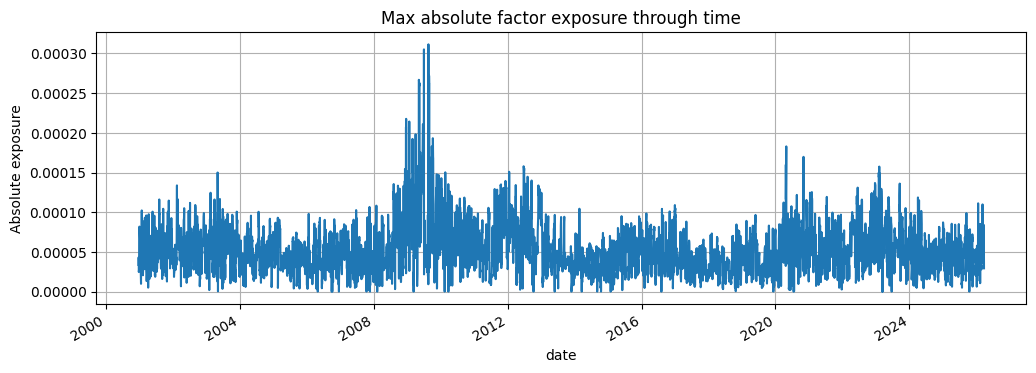

In [9]:
diag = result.diagnostics.copy()

fig, ax = plt.subplots(figsize=(12, 4))
diag["max_abs_factor_exposure"].plot(ax=ax)
ax.set_title("Max absolute factor exposure through time")
ax.set_ylabel("Absolute exposure")
ax.grid(True)
plt.show()

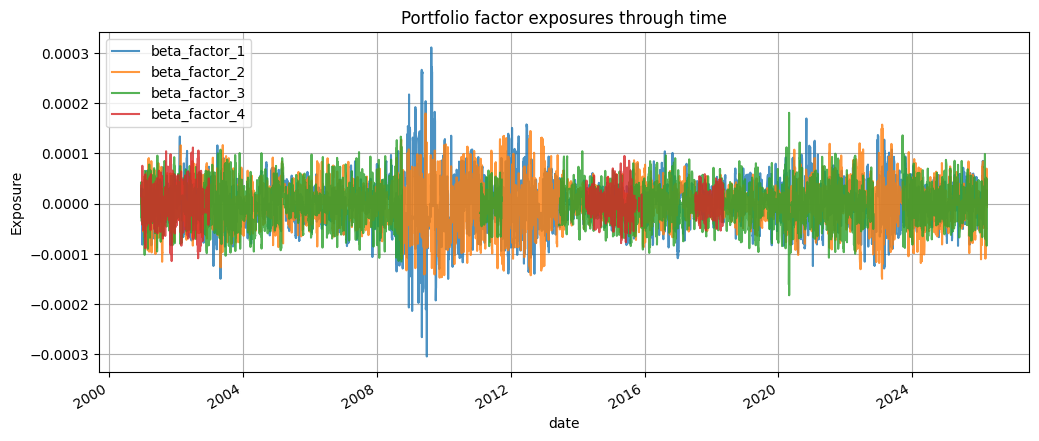

In [10]:
beta_cols = [c for c in result.diagnostics.columns if c.startswith("beta_")]

if beta_cols:
    fig, ax = plt.subplots(figsize=(12, 5))
    result.diagnostics[beta_cols].plot(ax=ax, alpha=0.8)
    ax.set_title("Portfolio factor exposures through time")
    ax.set_ylabel("Exposure")
    ax.grid(True)
    plt.show()
else:
    print("Pas de colonnes beta_.")

In [11]:
W = result.weights_history.copy()

print("Shape weights_history:", W.shape)
print("\nLast 5 dates:")
print(W.tail())

print("\nAverage absolute weight by stock:")
print(W.abs().mean().sort_values(ascending=False))

print("\nMax absolute weight by stock:")
print(W.abs().max().sort_values(ascending=False))

print("\nAverage gross exposure:")
print(W.abs().sum(axis=1).mean())

print("\nAverage net exposure:")
print(W.sum(axis=1).mean())

Shape weights_history: (6539, 13)

Last 5 dates:
                 AD1      CD1       EC1       SF1        C1       C01  \
2026-03-20 -0.004628  0.00215  0.004394 -0.048995  0.002058 -0.028117   
2026-03-23 -0.004628  0.00215  0.004394 -0.048995  0.002058 -0.021825   
2026-03-24 -0.004628  0.00215  0.004394 -0.048995  0.002058 -0.021825   
2026-03-25 -0.004628  0.00215  0.004394 -0.048995  0.002058 -0.021825   
2026-03-26 -0.004628  0.00215  0.004394 -0.048995  0.002058 -0.021825   

                 GC1       GX1       HG1       HI1       NQ1       VG1  \
2026-03-20  0.019638 -0.031287  0.019634 -0.018122 -0.007888 -0.006956   
2026-03-23  0.019638 -0.031287  0.019634 -0.018122 -0.007888 -0.006956   
2026-03-24  0.019638 -0.031287  0.019634 -0.018122 -0.002340 -0.006956   
2026-03-25  0.019638 -0.031287  0.019634 -0.018122 -0.002340 -0.006956   
2026-03-26  0.019638 -0.031287  0.019634 -0.018122 -0.002340 -0.006956   

                  W1  
2026-03-20  0.011089  
2026-03-23  0.011089 

In [12]:
W = result.weights_history.copy()

dominance = pd.DataFrame({
    "avg_abs_weight": W.abs().mean(),
    "max_abs_weight": W.abs().max(),
    "pct_days_active": (W.abs() > 1e-12).mean(),
    "avg_signed_weight": W.mean(),
}).sort_values("avg_abs_weight", ascending=False)

print(dominance)

     avg_abs_weight  max_abs_weight  pct_days_active  avg_signed_weight
EC1        0.018283        0.058662         1.000000           0.002435
AD1        0.018161        0.093430         1.000000           0.001610
HG1        0.017905        0.087000         0.997400          -0.001698
SF1        0.017484        0.073048         1.000000           0.002343
GC1        0.016928        0.067179         0.999847          -0.000781
CD1        0.016786        0.056288         0.999082           0.000345
GX1        0.016615        0.079459         1.000000           0.001026
C01        0.016612        0.067237         0.999847          -0.000732
VG1        0.015901        0.074401         1.000000           0.001880
NQ1        0.015778        0.065775         1.000000           0.000531
HI1        0.015184        0.071450         0.999847          -0.001920
C1         0.013170        0.067815         0.998777           0.000531
W1         0.013041        0.056981         0.999847          -0

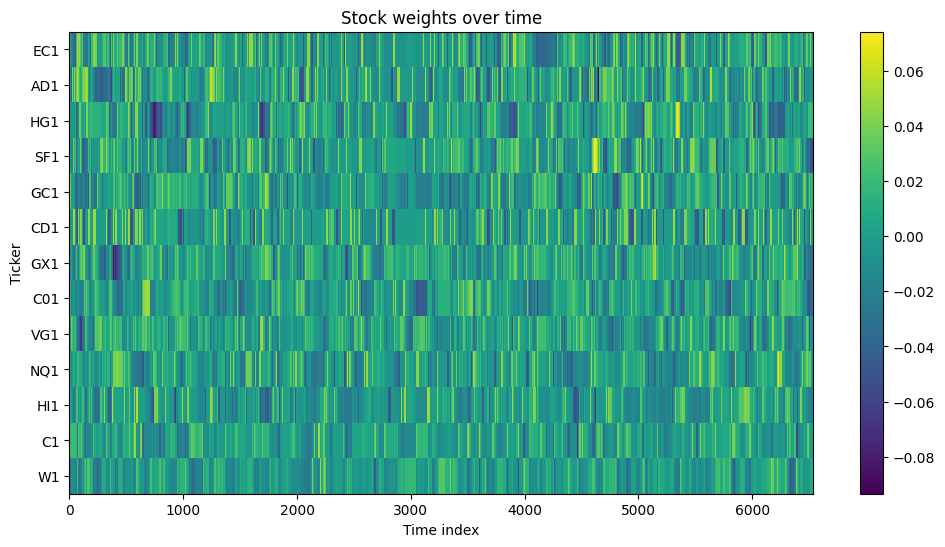

In [13]:
W = result.weights_history.copy()

top_names = W.abs().mean().sort_values(ascending=False).head(15).index
W_plot = W[top_names]

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(W_plot.T.values, aspect="auto", interpolation="nearest")
ax.set_title("Stock weights over time")
ax.set_yticks(range(len(top_names)))
ax.set_yticklabels(top_names)
ax.set_xlabel("Time index")
ax.set_ylabel("Ticker")
fig.colorbar(im, ax=ax)
plt.show()

Average changed names/day: 1.948768924912066
Median changed names/day: 0.0
Average gross weight change/day: 0.03362415087213527
Median gross weight change/day: 0.0


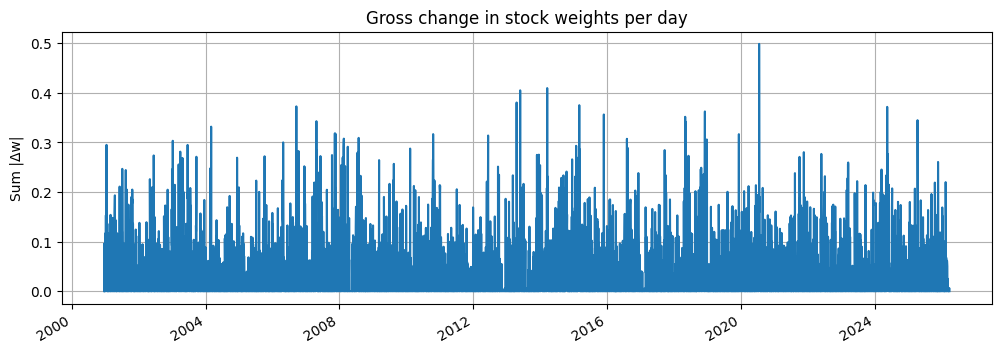

In [14]:
W = result.weights_history.copy()
delta_w = W.diff().fillna(0.0)

changed_names_per_day = (delta_w.abs() > 1e-10).sum(axis=1)
gross_weight_change_per_day = delta_w.abs().sum(axis=1)

print("Average changed names/day:", changed_names_per_day.mean())
print("Median changed names/day:", changed_names_per_day.median())
print("Average gross weight change/day:", gross_weight_change_per_day.mean())
print("Median gross weight change/day:", gross_weight_change_per_day.median())

fig, ax = plt.subplots(figsize=(12, 4))
gross_weight_change_per_day.plot(ax=ax)
ax.set_title("Gross change in stock weights per day")
ax.set_ylabel("Sum |Δw|")
ax.grid(True)
plt.show()

             gross          net  max_single_abs_weight     n_active
count  6539.000000  6539.000000            6539.000000  6539.000000
mean      0.211847     0.004560               0.043641    12.994647
std       0.059931     0.043266               0.010317     0.130188
min       0.051517    -0.175399               0.009379     6.000000
25%       0.170524    -0.022695               0.039341    13.000000
50%       0.209074     0.004215               0.045441    13.000000
75%       0.254625     0.031253               0.048901    13.000000
max       0.413443     0.183038               0.093430    13.000000


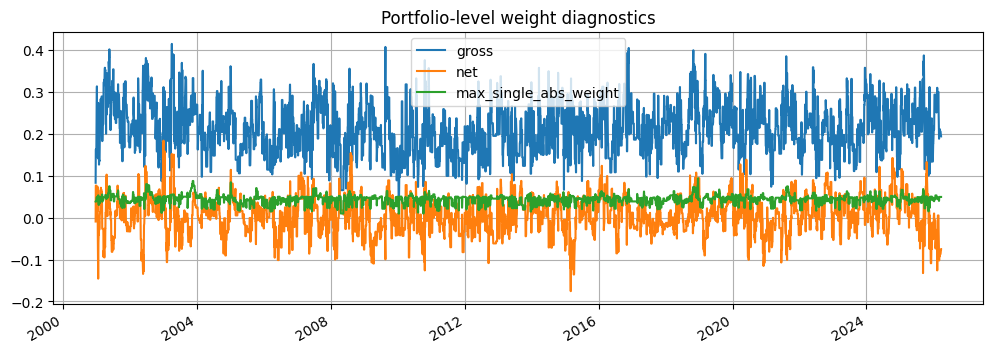

In [15]:
W = result.weights_history.copy()

gross = W.abs().sum(axis=1)
net = W.sum(axis=1)
max_single = W.abs().max(axis=1)
n_active = (W.abs() > 1e-12).sum(axis=1)

summary = pd.DataFrame({
    "gross": gross,
    "net": net,
    "max_single_abs_weight": max_single,
    "n_active": n_active,
})

print(summary.describe())

fig, ax = plt.subplots(figsize=(12, 4))
summary[["gross", "net", "max_single_abs_weight"]].plot(ax=ax)
ax.set_title("Portfolio-level weight diagnostics")
ax.grid(True)
plt.show()

In [16]:
date = result.diagnostics["max_abs_factor_exposure"].idxmax()
print("Worst date:", date)

print("\n=== Diagnostics on that date ===")
print(result.diagnostics.loc[date])

print("\n=== Weights on that date ===:")
print(result.weights_history.loc[date].sort_values(key=lambda s: s.abs(), ascending=False))

Worst date: 2009-08-18 00:00:00

=== Diagnostics on that date ===
n_assets                   13.000000
n_factors                   2.000000
selected_variance           0.622373
n_longs                     0.000000
n_shorts                    5.000000
gross_long                  0.153253
gross_short                 0.173094
gross                       0.326347
net                        -0.019841
turnover                    0.079821
trade_count                 2.000000
impact_cost                 0.000040
max_abs_factor_exposure     0.000311
beta_factor_1               0.000311
beta_factor_2              -0.000095
beta_factor_3                    NaN
beta_factor_4                    NaN
Name: 2009-08-18 00:00:00, dtype: float64

=== Weights on that date ===:
C1     0.045064
CD1   -0.044491
AD1   -0.043701
W1     0.040706
EC1   -0.034048
HG1    0.032204
GX1   -0.024015
VG1   -0.023296
C01    0.016891
HI1    0.011678
SF1    0.006709
NQ1   -0.001997
GC1   -0.001547
Name: 2009-08-18 00:00:0

In [17]:
diag = result.diagnostics.copy()
W = result.weights_history.copy()

beta_cols = [c for c in diag.columns if c.startswith("beta_")]

print("=== FACTOR NEUTRALITY ===")
if beta_cols:
    print(diag["max_abs_factor_exposure"].describe())
else:
    print("No factor exposures found.")

print("\n=== BOOK SHAPE ===")
print("Average gross:", W.abs().sum(axis=1).mean())
print("Average net:", W.sum(axis=1).mean())
print("Average max single weight:", W.abs().max(axis=1).mean())

print("\n=== TURNOVER / RESIZING ===")
dw = W.diff().fillna(0.0)
print("Average sum:", dw.abs().sum(axis=1).mean())
print("Average changed names:", (dw.abs() > 1e-10).sum(axis=1).mean())

print("\n=== DOMINANT NAMES ===")
print(W.abs().mean().sort_values(ascending=False).head(10))

=== FACTOR NEUTRALITY ===
count    6.539000e+03
mean     5.300464e-05
std      3.133145e-05
min      2.207171e-08
25%      3.166010e-05
50%      4.808731e-05
75%      6.752365e-05
max      3.114936e-04
Name: max_abs_factor_exposure, dtype: float64

=== BOOK SHAPE ===
Average gross: 0.21184709119881384
Average net: 0.004559974715902694
Average max single weight: 0.04364073651658474

=== TURNOVER / RESIZING ===
Average sum: 0.03362415087213527
Average changed names: 1.948768924912066

=== DOMINANT NAMES ===
EC1    0.018283
AD1    0.018161
HG1    0.017905
SF1    0.017484
GC1    0.016928
CD1    0.016786
GX1    0.016615
C01    0.016612
VG1    0.015901
NQ1    0.015778
dtype: float64


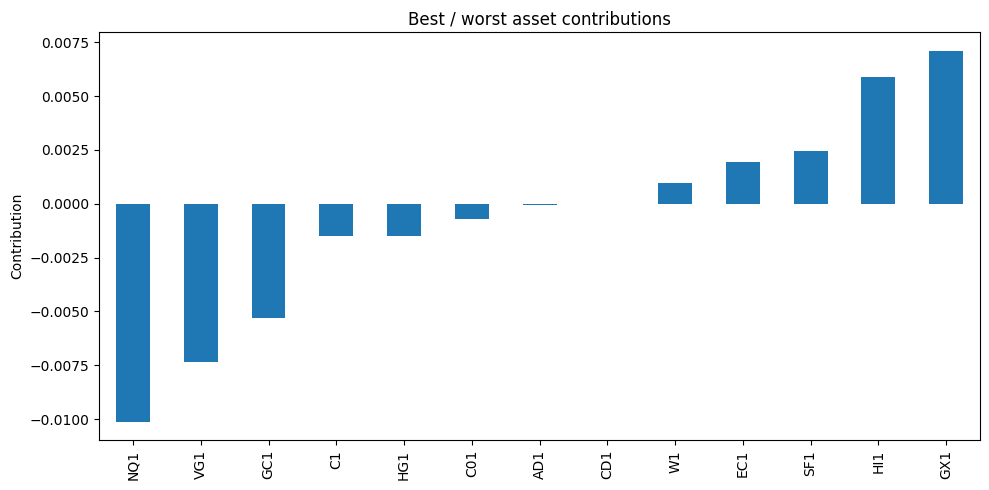

In [18]:
period_contrib = result.contribution_by_asset.loc["2025-01-01":"2025-12-12"].sum() # "2006-01-01":"2020-05-31"

plot_asset_contribution_bar(
    period_contrib,
    title="Best / worst asset contributions"
)

In [19]:
result.states_history[result.states_history.sum(axis=1)>2]
result.weights_history[result.weights_history.sum(axis=1)>0]
result.diagnostics[(result.diagnostics.n_longs > 0) | (result.diagnostics.n_shorts > 0)]

,n_assets,n_factors,selected_variance,n_longs,n_shorts,gross_long,gross_short,gross,net,turnover,trade_count,impact_cost,max_abs_factor_exposure,beta_factor_1,beta_factor_2,beta_factor_3,beta_factor_4
date,,,,,,,,,,,,,,,,,
2000-12-19,13,4,0.591709,0,1,0.036590,0.046145,0.082735,-0.009555,0.082735,1,0.000041,0.000034,0.000004,9.282429e-06,-0.000034,0.000014
2000-12-20,13,4,0.593006,1,1,0.119121,0.043144,0.162265,0.075978,0.095607,1,0.000048,0.000043,0.000013,-1.374804e-06,0.000043,0.000025
2000-12-21,13,4,0.593849,1,1,0.119121,0.043144,0.162265,0.075978,0.000000,0,0.000000,0.000038,0.000030,5.397971e-06,-0.000028,0.000038
2000-12-22,13,4,0.592549,1,1,0.119121,0.043144,0.162265,0.075978,0.000000,0,0.000000,0.000025,0.000025,2.454177e-06,0.000019,-0.000001
2000-12-26,13,4,0.593679,1,1,0.119121,0.043144,0.162265,0.075978,0.000000,0,0.000000,0.000030,-0.000030,1.377024e-05,-0.000009,-0.000021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-20,13,3,0.600047,0,2,0.058963,0.145993,0.204957,-0.087030,0.000000,0,0.000000,0.000045,0.000009,3.502411e-05,0.000045,NaN
2026-03-23,13,3,0.598525,0,2,0.058963,0.139701,0.198665,-0.080738,0.006292,0,0.000003,0.000070,0.000027,6.972189e-05,0.000050,NaN
2026-03-24,13,3,0.594097,0,2,0.058963,0.134153,0.193116,-0.075189,0.005549,0,0.000003,0.000084,0.000014,2.936296e-05,-0.000084,NaN


### Strategy time snapshots

In [20]:
date = sorted(result.snapshots.keys())[2]
snap = result.snapshots[date]

# snap.correlation_matrix.head()
# snap.eigenvalues[:10]
# snap.eigenvectors.iloc[:5, :5]
# snap.ou_table.head()
# snap.full_score.sort_values().dropna().head(10)

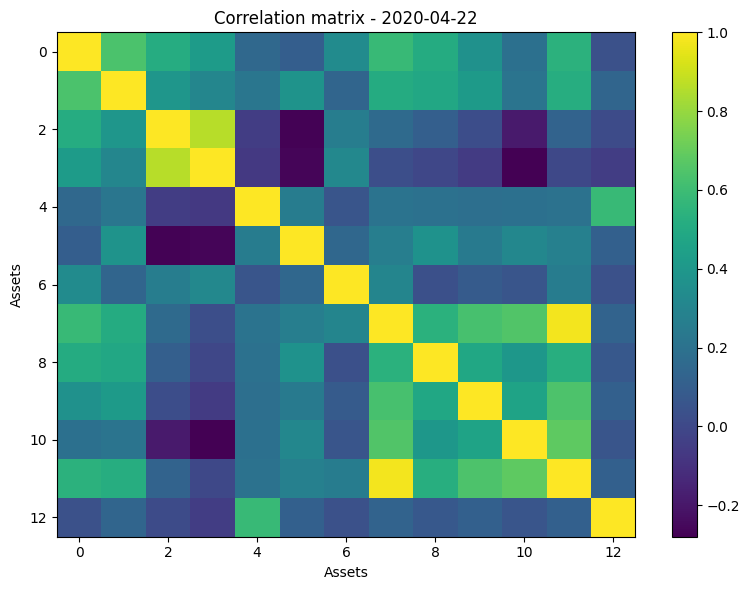

In [21]:
plot_correlation_matrix(
    snap.correlation_matrix,
    title=f"Correlation matrix - {date.date()}"
)

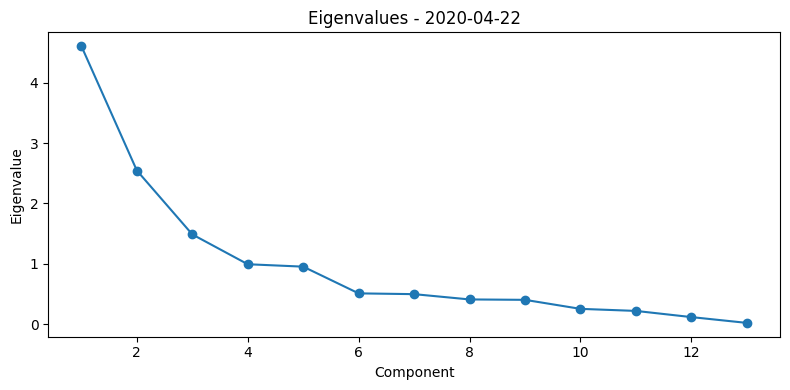

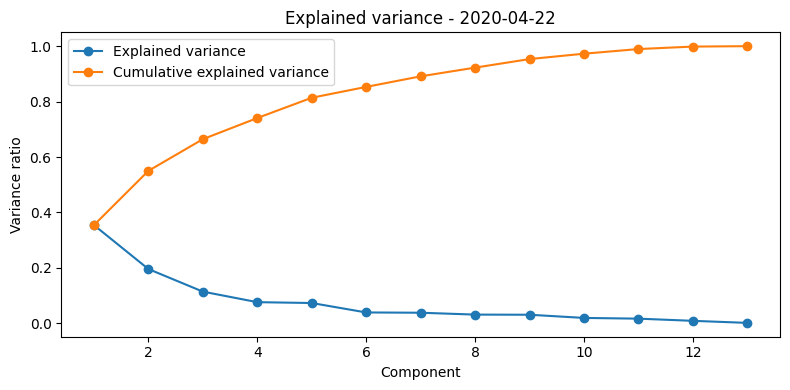

In [22]:
plot_scree(snap.eigenvalues, title=f"Eigenvalues - {date.date()}")
plot_explained_variance(snap.eigenvalues, title=f"Explained variance - {date.date()}")

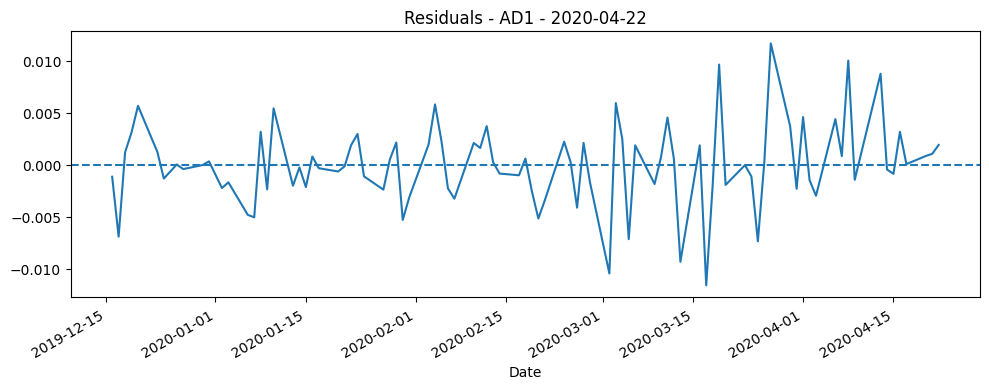

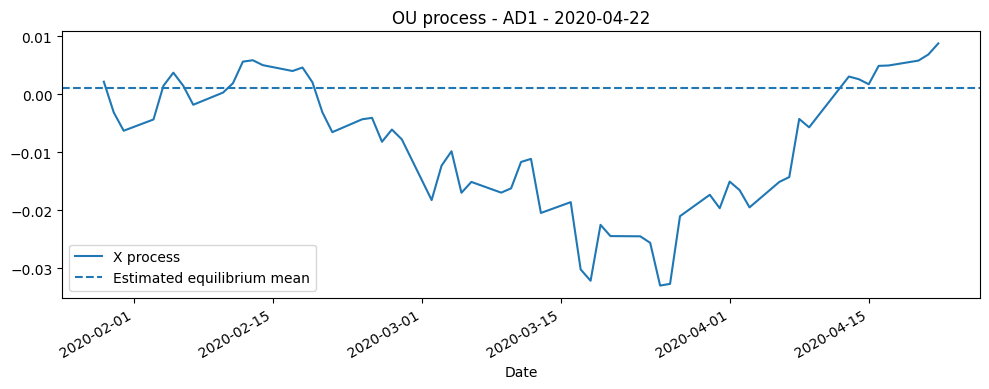

In [23]:
ticker = snap.ou_table.index[0]

plot_residuals( 
    snap.residuals_window[ticker],
    title=f"Residuals - {ticker} - {date.date()}"
)

plot_ou_process(
    snap.x_process_window[ticker],
    equilibrium_mean=snap.ou_table.loc[ticker, "m"],
    title=f"OU process - {ticker} - {date.date()}"
)

### Compare strategies

In [24]:
cfg_fixed = make_pca_config()
cfg_fixed.pca_mode = "fixed"
cfg_fixed.n_factors_fixed = 5
cfg_fixed.sbo = 2.0
cfg_fixed.sso = 2.0
cfg_fixed.sbc = 0.5
cfg_fixed.ssc = 0.5
cfg_fixed.validate()

res_fixed = run_backtest(prices, cfg_fixed)

summary_fixed = summarize_backtest(
    equity_curve=res_fixed.equity_curve,
    daily_returns=res_fixed.daily_returns,
    turnover=res_fixed.turnover,
    nb_trades=res_fixed.total_trade_count
)

summary_fixed

total_return           -0.033041
annualized_return      -0.001294
annualized_vol          0.008509
sharpe                 -0.147913
max_drawdown           -0.054724
hit_ratio               0.489983
nb_trades            3448.000000
avg_turnover            0.028116
median_turnover         0.000000
Name: performance, dtype: float64

In [25]:
cfg_var = make_pca_config()
cfg_var.pca_mode = "variance"
cfg_var.explained_variance_target = 0.55
cfg_var.sbo = 1.25 
cfg_var.sso = 1.25 
cfg_var.sbc = 0.75 
cfg_var.ssc = 0.5
cfg_var.validate()

res_var = run_backtest(prices, cfg_var)

summary_var = summarize_backtest(
    equity_curve=res_var.equity_curve,
    daily_returns=res_var.daily_returns,
    turnover=res_var.turnover,
    nb_trades= res_var.total_trade_count
)
summary_var

total_return           -0.123466
annualized_return      -0.005066
annualized_vol          0.014627
sharpe                 -0.339879
max_drawdown           -0.139753
hit_ratio               0.484631
nb_trades            8708.000000
avg_turnover            0.070884
median_turnover         0.059969
Name: performance, dtype: float64

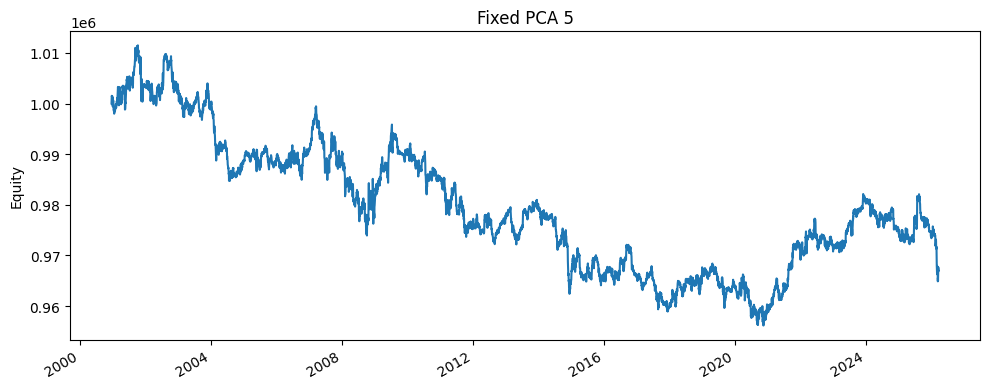

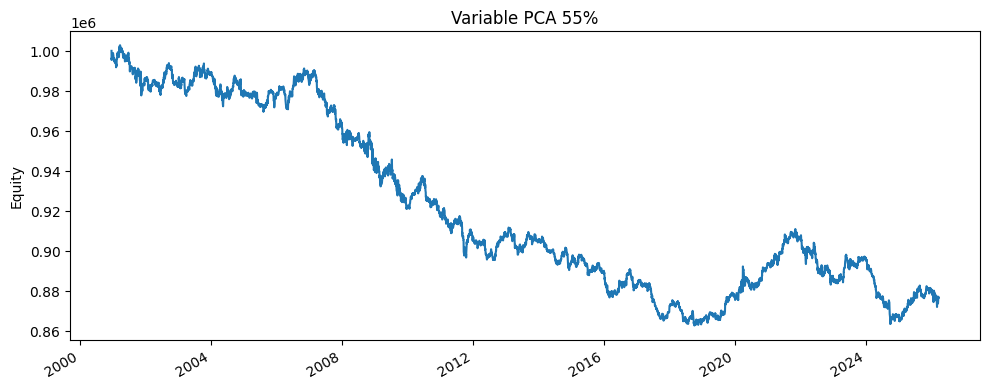

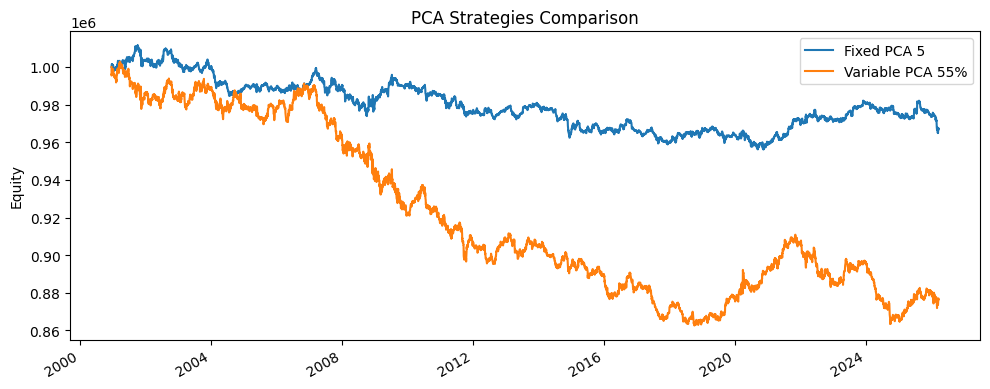

In [26]:
plot_equity_curve(res_fixed.equity_curve, title=f"Fixed PCA {cfg_fixed.n_factors_fixed}")
plot_equity_curve(res_var.equity_curve, title=f"Variable PCA {cfg_var.explained_variance_target*100:.0f}%")
plot_strategy_comparison(
    {
        f"Fixed PCA {cfg_fixed.n_factors_fixed}": res_fixed.equity_curve,
        f"Variable PCA {cfg_var.explained_variance_target*100:.0f}%": res_var.equity_curve,
    },
    title="PCA Strategies Comparison",
)